In [1]:
import numpy as np
from scipy import special
import scipy
import random
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
from smt.sampling_methods import LHS
from scipy.optimize import bisect
import pingouin as pg

from scipy.stats import t

In [2]:
# Parameter baselines - # 6 parametres au total + N: pop totle
Lambdab = 5000
betab = 0.5
gammab = 0.1
alphab = 0.09
mub = 0.0019 
deltab = 0.09
#NTb = 8500

In [3]:
## Value parameters We assume uniform distribution for all the parameter values
N = 2000

Lambda = np.random.uniform(Lambdab*0.7, Lambdab*1.3, N)
beta = np.random.uniform(betab*0.7, betab*1.3, N)
gamma = np.random.uniform(gammab*0.7, gammab*1.3, N)
alpha = np.random.uniform(alphab*0.7, alphab*1.3, N)
mu = np.random.uniform(mub*0.7, mub*1.3, N) 
delta = np.random.uniform(deltab*0.7, deltab*1.3, N)
#NT = np.random.uniform(NTb*0.7, NTb*1.3, N)


#Shuffle list of parameter values (lecture aleatoire)

random.shuffle(Lambda)
random.shuffle(beta)
random.shuffle(gamma)
random.shuffle(alpha)
random.shuffle(mu)
random.shuffle(delta)
#random.shuffle(NT)


LHmatrics = []
for i in range(N): 
    LHmatrics.append([Lambda[i], beta[i], gamma[i], alpha[i], mu[i], delta[i]])#, NT[i]])


In [4]:
headerList = ['Lambda', 'beta', 'gamma', 'alpha', 'mu', 'delta'] #, 'NT']
df2 = pd.DataFrame(LHmatrics)
df2.to_csv("parameter_combination_marius_R_0.csv", header=headerList, index=False)

In [5]:
# reading dataframe
df2 = pd.read_csv("parameter_combination_marius_R_0.csv")
df2

,Lambda,beta,gamma,alpha,mu,delta
0,4502.321526,0.590340,0.101983,0.072295,0.001973,0.068390
1,5798.903492,0.544900,0.089279,0.097365,0.001885,0.090887
2,3795.484113,0.546126,0.098188,0.098906,0.001837,0.103811
3,3699.625528,0.432635,0.103016,0.088934,0.001721,0.091221
4,3734.910584,0.583195,0.085529,0.069104,0.002114,0.086068
...,...,...,...,...,...,...
1995,5543.772244,0.446562,0.094408,0.070694,0.001799,0.068996
1996,4695.668303,0.357733,0.113608,0.074777,0.001759,0.094853
1997,4635.812253,0.540483,0.117227,0.081679,0.002455,0.087640
1998,6418.321111,0.555584,0.125224,0.077891,0.001826,0.102776


$$\mathcal{R}_0=\frac{\beta\Lambda}{\mu(\alpha+\gamma+\mu+\delta)}$$

In [6]:
def calculate_R0(Lambda, beta, gamma, alpha, mu, delta):
    
    # Calcul de R0
    
    r0 = beta * Lambda / ( mu * (alpha + gamma + mu + delta))
    
    return r0

In [7]:
# Calculate R0 for all samples
df2['R0'] = df2.apply(lambda row: calculate_R0(
    row['Lambda'], row['beta'], row['gamma'], row['alpha'], row['mu'], row['delta']
   ), axis=1)

In [8]:
df2

,Lambda,beta,gamma,alpha,mu,delta,R0
0,4502.321526,0.590340,0.101983,0.072295,0.001973,0.068390,5.505647e+06
1,5798.903492,0.544900,0.089279,0.097365,0.001885,0.090887,6.000378e+06
2,3795.484113,0.546126,0.098188,0.098906,0.001837,0.103811,3.727332e+06
3,3699.625528,0.432635,0.103016,0.088934,0.001721,0.091221,3.264598e+06
4,3734.910584,0.583195,0.085529,0.069104,0.002114,0.086068,4.243542e+06
...,...,...,...,...,...,...,...
1995,5543.772244,0.446562,0.094408,0.070694,0.001799,0.068996,5.834590e+06
1996,4695.668303,0.357733,0.113608,0.074777,0.001759,0.094853,3.350872e+06
1997,4635.812253,0.540483,0.117227,0.081679,0.002455,0.087640,3.531605e+06
1998,6418.321111,0.555584,0.125224,0.077891,0.001826,0.102776,6.345219e+06


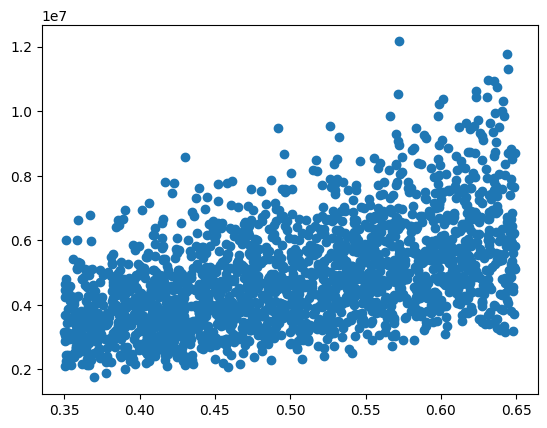

In [9]:
plt.scatter(df2['beta'], df2['R0'])
#plt.savefig("PRCC_R0.pdf", bbox_inches='tight') # To save the figure
plt.show()

In [10]:
## PRCC values 
prcc_inc = pd.DataFrame({'prcc' : [],
                       't-stat':[],
                       'p-value' : []})
print(headerList)
prcc = []
tvalue = []
pvalue = []
for i in headerList:
    tamp = []
    tamp = pg.partial_corr(data=df2, x=i, y='R0', method='spearman')
    prcc.append(tamp['r'].values[0])
    tt = tamp['r'].values[0]*np.sqrt((N-3-2)/(1-tamp['r'].values[0]**2))
    #print(tt)
    #print(scipy.stats.t.sf(np.abs(tt), N-1)*2)
    tvalue.append(tt)
    pvalue.append(tamp['p-val'].values[0])
prcc_inc['prcc'] = prcc
prcc_inc['t-stat'] = tvalue
prcc_inc['p-value'] = pvalue
#print(prcc_inc)

['Lambda', 'beta', 'gamma', 'alpha', 'mu', 'delta']


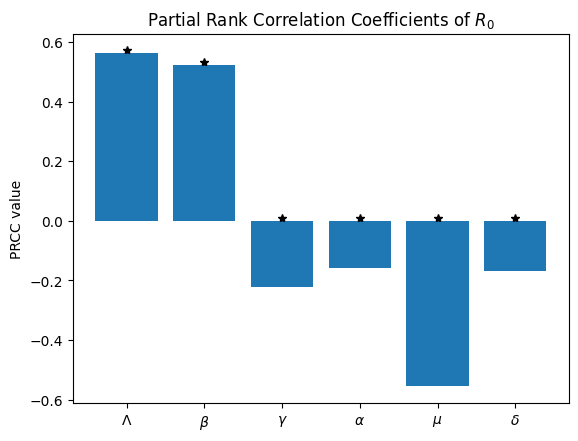

In [11]:
fig,ax=plt.subplots(1,1)
xp=[i for i in range(6)]
ax.bar(xp,prcc_inc['prcc'], align='center')

bLabels = list([r'$\Lambda$', r'$\beta$', r'$\gamma$', r'$\alpha$', r'$\mu$', r'$\delta$'])

ax.set_xticks(xp, bLabels)

ax.set_ylabel('PRCC value');
for i in range (6):
    if prcc_inc['p-value'][i]<0.01:
        if prcc_inc['prcc'][i]<0:
            ax.plot(i,0.01, marker='*', color='black')
        else:
            ax.plot(i,prcc_inc['prcc'][i]+0.01, marker='*', color='black')

#fig.savefig("prcc_R0.pdf", bbox_inches='tight')
plt.title('Partial Rank Correlation Coefficients of $R_0$')
plt.savefig("PRCC_R0.pdf", bbox_inches='tight')
plt.show()

The PRCC analysis highlights the relative influence of each parameter on the basic reproduction number $\mathcal{R}_0$. The results show that the recruitment rate $\Lambda$ and the transmission rate $\beta$ have the strongest positive impact on $\mathcal{R}_0$, indicating that an increase in either parameter significantly enhances disease transmission within the population.

On the other hand, the natural death rate $\mu$ exhibits the strongest negative influence, suggesting that higher mortality reduces the spread of the infection. The recovery-related parameters $\gamma$ and $\alpha$, as well as the disease-induced death rate $\delta$, also contribute negatively, although their effects are more moderate. 

Overall, these results confirm that transmission and recruitment drive the spread of the disease, while recovery and mortality mechanisms act as limiting factors.
